# Setup


In [1]:
import numpy as np
import pandas as pd
import pathlib
import pickle
import json
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.io as pio

# Definisikan Konstanta Global
PROCESSED_DIR = pathlib.Path('../data/processed')
MODELS_DIR = pathlib.Path('../models')
FIGURES_DIR = pathlib.Path('../reports/figures')

# Buat direktori figure jika belum ada
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# 1. Load Data Cleaned untuk referensi tanggal dan candlestick
df_clean = pd.read_csv(PROCESSED_DIR / 'data_antam_clean.csv')
df_clean['Tanggal'] = pd.to_datetime(df_clean['Tanggal'])
df_clean.set_index('Tanggal', inplace=True)

# 2. Load array Aktual dan Prediksi
y_test = np.load(PROCESSED_DIR / 'y_test.npy')
y_pred_baseline = np.load(PROCESSED_DIR / 'y_pred_baseline_inv.npy')
y_pred_lstm = np.load(PROCESSED_DIR / 'y_pred_lstm_inv.npy')
y_pred_gru = np.load(PROCESSED_DIR / 'y_pred_gru_inv.npy')
y_pred_hybrid = np.load(PROCESSED_DIR / 'y_pred_hybrid_inv.npy')

# 3. Load Scaler untuk inverse transform y_test ke harga rupiah asli
with open(MODELS_DIR / 'scaler_y.pkl', 'rb') as f:
    scaler_y = pickle.load(f)

y_actual = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()

# 4. Load Hasil Metrik (sebagai referensi untuk anotasi label grafik)
with open(MODELS_DIR / 'results_summary.json', 'r') as f:
    metrics = json.load(f)

# 5. Ambil indeks tanggal khusus Test Set (236 baris terakhir)
test_dates = df_clean.index[-len(y_actual):]

print("=== Konfirmasi Setup ===")
print("Semua data aktual, data prediksi, dan metrik model berhasil dimuat.")
print(f"Rentang tanggal test set: {test_dates[0].strftime('%Y-%m-%d')} s/d {test_dates[-1].strftime('%Y-%m-%d')} ({len(test_dates)} hari perdagangan)")

# Import tambahan untuk Forecasting
from tensorflow.keras.models import load_model


=== Konfirmasi Setup ===
Semua data aktual, data prediksi, dan metrik model berhasil dimuat.
Rentang tanggal test set: 2025-05-08 s/d 2026-05-05 (236 hari perdagangan)


I0000 00:00:1779147378.239483  163247 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779147378.239854  163247 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779147378.274333  163247 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1779147379.367158  163247 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779147379.367396  163247 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


# Candlestick Chart Interaktif


In [2]:
# Filter DataFrame hanya untuk data mulai tahun 2024
df_2yr = df_clean[df_clean.index >= '2024-01-01']

fig_candle = go.Figure()

# Trace 1: Candlestick
fig_candle.add_trace(go.Candlestick(
    x=df_2yr.index,
    open=df_2yr['Pembukaan'],
    high=df_2yr['Tertinggi'],
    low=df_2yr['Terendah'],
    close=df_2yr['Terakhir'],
    name='OHLC',
    increasing_line_color='#26A69A', # Hijau teal
    decreasing_line_color='#EF5350'  # Merah
))

# Trace 2: Moving Average 7 hari (MA7)
fig_candle.add_trace(go.Scatter(
    x=df_2yr.index,
    y=df_2yr['MA7'],
    name='MA7',
    line=dict(color='blue', width=1.5),
    opacity=0.8
))

# Trace 3: Moving Average 30 hari (MA30)
fig_candle.add_trace(go.Scatter(
    x=df_2yr.index,
    y=df_2yr['MA30'],
    name='MA30',
    line=dict(color='orange', width=2),
    opacity=0.9
))

# Konfigurasi Layout
fig_candle.update_layout(
    title='Pergerakan Harga Saham ANTM (2024-2026) — Candlestick + MA',
    xaxis_title='Tanggal',
    yaxis_title='Harga (Rp)',
    template='plotly_white',
    height=500,
    xaxis_rangeslider_visible=False, # Sembunyikan rangeslider bawah agar lebih rapi
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01,
        bgcolor='rgba(255, 255, 255, 0.8)'
    )
)

# Simpan sebagai file HTML interaktif
pio.write_html(fig_candle, file=str(FIGURES_DIR / 'candlestick_antam.html'))

# Tampilkan di cell ini
fig_candle.show()


# Grafik Prediksi vs Aktual (Interaktif)


In [3]:
fig_pred = go.Figure()

# Trace 1: Harga Aktual
fig_pred.add_trace(go.Scatter(
    x=test_dates, 
    y=y_actual,
    name='Aktual', 
    line=dict(color='#1565C0', width=2.5) # Biru tebal
))

# Trace 2: Prediksi Baseline
fig_pred.add_trace(go.Scatter(
    x=test_dates, 
    y=y_pred_baseline,
    name=f"Baseline (MAPE: {metrics['baseline']['mape']:.2f}%)",
    line=dict(color='#9E9E9E', width=1.5, dash='dash') # Abu-abu dashed
))

# Trace 3: Prediksi GRU
fig_pred.add_trace(go.Scatter(
    x=test_dates, 
    y=y_pred_gru,
    name=f"GRU (MAPE: {metrics['gru']['mape']:.2f}%)",
    line=dict(color='#2E7D32', width=1.8) # Hijau
))

# Trace 5: Prediksi Hybrid
fig_pred.add_trace(go.Scatter(
    x=test_dates, 
    y=y_pred_hybrid,
    name=f"Hybrid (MAPE: {metrics['hybrid']['mape']:.2f}%)",
    line=dict(color='#8E24AA', width=1.8) # Ungu
))

# Trace 4: Prediksi LSTM
fig_pred.add_trace(go.Scatter(
    x=test_dates, 
    y=y_pred_lstm,
    name=f"LSTM (MAPE: {metrics['lstm']['mape']:.2f}%)",
    line=dict(color='#E65100', width=1.8) # Oranye gelap
))

# Konfigurasi Layout
fig_pred.update_layout(
    title='Prediksi vs Aktual Harga Saham ANTM — Test Set (Jan 2025–Mei 2026)',
    xaxis_title='Tanggal',
    yaxis_title='Harga (Rp)',
    template='plotly_white',
    height=500,
    hovermode='x unified', # Crosshair agar nilai hover tampil semua per sumbu X
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01,
        bgcolor='rgba(255, 255, 255, 0.8)'
    )
)

# Simpan sebagai HTML
pio.write_html(fig_pred, file=str(FIGURES_DIR / 'prediction_vs_actual.html'))

# Tampilkan plot
fig_pred.show()


# Metrik Comparison Bar Chart


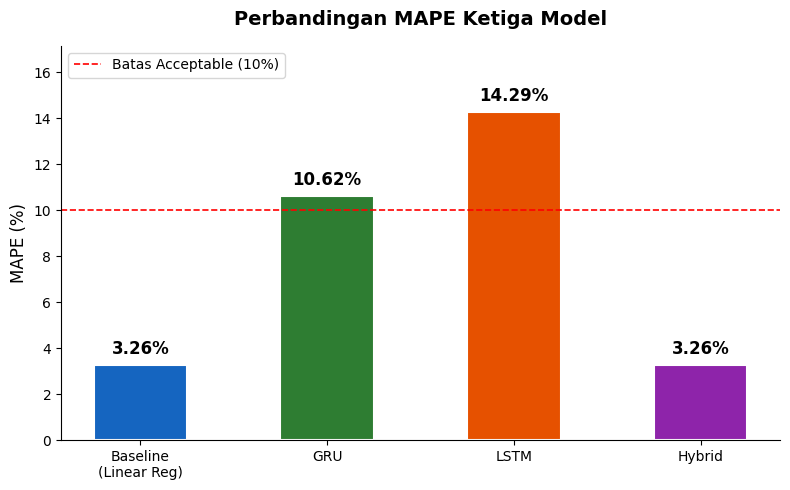

In [4]:
# Data untuk Plot
models = ['Baseline\n(Linear Reg)', 'GRU', 'LSTM', 'Hybrid']
mapes  = [metrics['baseline']['mape'], metrics['gru']['mape'], metrics['lstm']['mape'], metrics['hybrid']['mape']]
colors = ['#1565C0', '#2E7D32', '#E65100', '#8E24AA']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(models, mapes, color=colors, width=0.5, edgecolor='white', linewidth=1.5)

# Anotasi teks nilai di puncak tiap bar
for bar, val in zip(bars, mapes):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{val:.2f}%', 
        ha='center', 
        va='bottom',
        fontweight='bold', 
        fontsize=12
    )

# Garis referensi Toleransi (Misal: 10% Margin of Error)
ax.axhline(y=10, color='red', linestyle='--', linewidth=1.2, label='Batas Acceptable (10%)')

# Estetika Grafik
ax.set_title('Perbandingan MAPE Ketiga Model', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('MAPE (%)', fontsize=12)
ax.set_ylim(0, max(mapes) * 1.2)
ax.legend(loc='upper left')

# Menghilangkan garis tepi atas & kanan (Spines) agar terlihat modern
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'mape_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


# Feature Correlation Heatmap


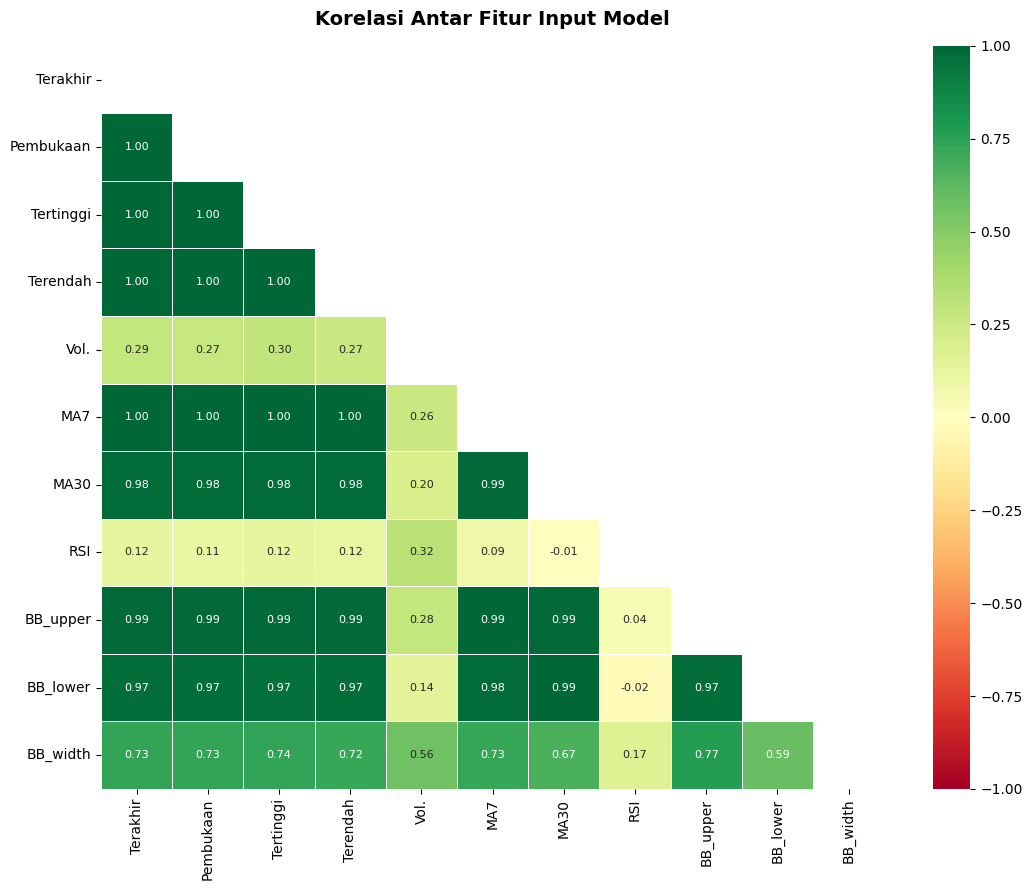

In [5]:
features = [
    'Terakhir', 'Pembukaan', 'Tertinggi', 'Terendah',
    'Vol.', 'MA7', 'MA30', 'RSI', 
    'BB_upper', 'BB_lower', 'BB_width'
]

# Hitung Matriks Korelasi Pearson
corr = df_clean[features].corr()

fig, ax = plt.subplots(figsize=(11, 9))

# Memotong visualisasi menjadi setengah segitiga agar tidak redundant
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr, 
    mask=mask, 
    annot=True, 
    fmt='.2f',
    cmap='RdYlGn', 
    vmin=-1, 
    vmax=1,
    linewidths=0.5, 
    ax=ax,
    annot_kws={'size': 8}
)

ax.set_title('Korelasi Antar Fitur Input Model', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'feature_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


# Ringkasan Figure yang Dihasilkan


In [6]:
import os

files = [
    'candlestick_antam.html',
    'prediction_vs_actual.html',
    'mape_comparison.png',
    'feature_correlation_heatmap.png',
    'forecast_30hari.html',
]

print("=== Verifikasi Output Visualisasi ===")
for f in files:
    path = FIGURES_DIR / f
    status = "✅ ADA" if path.exists() else "❌ TIDAK ADA"
    size = f"({path.stat().st_size / 1024:.1f} KB)" if path.exists() else ""
    print(f"{status} {f} {size}")


=== Verifikasi Output Visualisasi ===
✅ ADA candlestick_antam.html (4818.5 KB)
✅ ADA prediction_vs_actual.html (4781.7 KB)
✅ ADA mape_comparison.png (43.8 KB)
✅ ADA feature_correlation_heatmap.png (99.5 KB)
✅ ADA forecast_30hari.html (4742.4 KB)


# BAGIAN 6 — Forecasting: 1 Hari ke Depan (Single Step)


In [7]:
# Konstanta Forecasting
FORECAST_DAYS = 30

# Load Model Deep Learning (HANYA GRU karena merupakan yang terbaik di deep learning)
model_gru_residual = load_model(MODELS_DIR / 'gru_residual_antam.h5', compile=False)
with open(MODELS_DIR / 'baseline_model.pkl', 'rb') as f:
    model_baseline = pickle.load(f)

# Load Scaler Fitur
with open(MODELS_DIR / 'scaler_X.pkl', 'rb') as f:
    scaler_X = pickle.load(f)

# Definisikan features secara terurut
features = [
    'Terakhir', 'Pembukaan', 'Tertinggi', 'Terendah',
    'Vol.', 'MA7', 'MA30', 'RSI', 'BB_upper',
    'BB_lower', 'BB_width'
]

# Ambil 60 hari terakhir dari dataset aktual
last_60 = df_clean[features].values[-60:]

# Normalisasi dengan scaler_X (hanya .transform())
last_60_scaled = scaler_X.transform(last_60)

# Reshape untuk input model rekursif (1 sampel, 60 time steps, 11 features)
X_input_single = last_60_scaled.reshape(1, 60, len(features))

# Prediksi 1 hari ke depan
pred_res_scaled_single = model_gru_residual.predict(X_input_single, verbose=0).flatten()
pred_lr_scaled_single = model_baseline.predict(X_input_single.reshape(1, -1))
pred_scaled_single = pred_lr_scaled_single + pred_res_scaled_single
pred_price_single = scaler_y.inverse_transform(pred_scaled_single.reshape(-1, 1))[0][0]

# Hitung tanggal prediksi (hari trading berikutnya, skip weekend)
next_date = pd.bdate_range(
    start=df_clean.index[-1] + pd.Timedelta(days=1),
    periods=1
)[0]

# Hitung persentase perubahan dari hari terakhir
last_price = df_clean['Terakhir'].iloc[-1]
price_change = pred_price_single - last_price
price_change_pct = (price_change / last_price) * 100

print("=" * 50)
print("PREDIKSI HARGA ANTM — SINGLE STEP")
print("=" * 50)
print(f"Tanggal Prediksi  : {next_date.strftime('%d %B %Y')}")
print(f"Harga Terakhir    : Rp {last_price:,.0f}")
print(f"Prediksi Harga    : Rp {pred_price_single:,.0f}")
print(f"Estimasi Perubahan: {price_change:+,.0f} ({price_change_pct:+.2f}%)")
arah = "NAIK ▲" if price_change > 0 else "TURUN ▼"
print(f"Arah              : {arah}")
print("=" * 50)
print("⚠️  Disclaimer: Prediksi ini hanya berdasarkan")
print("    pola historis. Bukan saran investasi.")


E0000 00:00:1779147381.537461  163247 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
/home/muba/Work/Projects/uas-prediksi-saham/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


PREDIKSI HARGA ANTM — SINGLE STEP
Tanggal Prediksi  : 06 May 2026
Harga Terakhir    : Rp 3,690
Prediksi Harga    : Rp 3,709
Estimasi Perubahan: +19 (+0.51%)
Arah              : NAIK ▲
⚠️  Disclaimer: Prediksi ini hanya berdasarkan
    pola historis. Bukan saran investasi.


# Forecasting: 30 Hari ke Depan (Multi Step)


In [8]:
# ── Persiapan window awal ──────────────────────────────────────
# Ambil 60 baris terakhir aktual
window_raw = df_clean[features].values[-60:].copy()

# Hitung proksi stabilitas untuk fitur turunan
# Indeks fitur: 0=Terakhir, 1=Pembukaan, 2=Tertinggi, 3=Terendah,
#               4=Vol., 5=MA7, 6=MA30, 7=RSI, 8=BB_upper,
#               9=BB_lower, 10=BB_width
mean_features = df_clean[features].tail(60).mean().values

# ── Loop forecasting rekursif ──────────────────────────────────
forecast_prices = []
forecast_dates  = []

# Konstruksi rentang tanggal 30 hari trading ke depan
future_dates = pd.bdate_range(
    start=df_clean.index[-1] + pd.Timedelta(days=1),
    periods=FORECAST_DAYS
)

current_window = window_raw.copy()

last_price = df_clean['Terakhir'].iloc[-1]
max_price = last_price * 1.30
min_price = last_price * 0.70

for i in range(FORECAST_DAYS):
    # 1. Normalisasi window saat ini (sudah dalam skala raw)
    window_scaled = scaler_X.transform(current_window)

    # 2. Prediksi dalam skala normalized
    X_input = window_scaled.reshape(1, 60, len(features))

    # GRU residual prediksi residual (dalam skala normalized)
    pred_res_scaled = model_gru_residual.predict(
        X_input, verbose=0).flatten()[0]

    # Baseline prediksi tren (dalam skala normalized)
    pred_lr_scaled = model_baseline.predict(
        X_input.reshape(1, -1))[0]

    # Gabungkan dalam skala normalized
    pred_combined_scaled = pred_lr_scaled + pred_res_scaled

    # Inverse transform ke Rupiah HANYA untuk disimpan
    pred_price = scaler_y.inverse_transform(
        [[pred_combined_scaled]])[0][0]

    # Guardrail: Batasi prediksi agar tidak lebih dari ±30% dari harga terakhir
    pred_price = np.clip(pred_price, min_price, max_price)

    forecast_prices.append(pred_price)
    forecast_dates.append(future_dates[i])

    # 3. Bangun baris baru dalam skala RAW (bukan normalized)
    #    agar scaler_X.transform() di iterasi berikutnya konsisten
    new_row = mean_features.copy()
    new_row[0] = pred_price        # Terakhir (Rupiah)
    new_row[1] = pred_price        # Pembukaan (proxy)
    new_row[2] = pred_price * 1.005  # Tertinggi (+0.5%)
    new_row[3] = pred_price * 0.995  # Terendah (-0.5%)

    # 4. Geser window dalam skala RAW
    current_window = np.vstack([current_window[1:], new_row])

# ── Buat DataFrame hasil forecast ──────────────────────────────
df_forecast = pd.DataFrame({
    'Tanggal': forecast_dates,
    'Prediksi_Harga': forecast_prices
}).set_index('Tanggal')

print("=== Hasil Forecast 30 Hari ke Depan ===\n")
print(df_forecast.to_string())


/home/muba/Work/Projects/uas-prediksi-saham/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/muba/Work/Projects/uas-prediksi-saham/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/muba/Work/Projects/uas-prediksi-saham/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/muba/Work/Projects/uas-prediksi-saham/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


/home/muba/Work/Projects/uas-prediksi-saham/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/muba/Work/Projects/uas-prediksi-saham/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/muba/Work/Projects/uas-prediksi-saham/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/muba/Work/Projects/uas-prediksi-saham/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


/home/muba/Work/Projects/uas-prediksi-saham/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/muba/Work/Projects/uas-prediksi-saham/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/muba/Work/Projects/uas-prediksi-saham/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/muba/Work/Projects/uas-prediksi-saham/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


/home/muba/Work/Projects/uas-prediksi-saham/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/muba/Work/Projects/uas-prediksi-saham/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/muba/Work/Projects/uas-prediksi-saham/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/muba/Work/Projects/uas-prediksi-saham/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


/home/muba/Work/Projects/uas-prediksi-saham/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/muba/Work/Projects/uas-prediksi-saham/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/muba/Work/Projects/uas-prediksi-saham/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/muba/Work/Projects/uas-prediksi-saham/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/muba/Work/Projects/uas-prediksi-saham/.venv/lib/python3.11/site-packages/sklearn/utils

/home/muba/Work/Projects/uas-prediksi-saham/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/muba/Work/Projects/uas-prediksi-saham/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/muba/Work/Projects/uas-prediksi-saham/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/muba/Work/Projects/uas-prediksi-saham/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/muba/Work/Projects/uas-prediksi-saham/.venv/lib/python3.11/site-packages/sklearn/utils

/home/muba/Work/Projects/uas-prediksi-saham/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/muba/Work/Projects/uas-prediksi-saham/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/muba/Work/Projects/uas-prediksi-saham/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/muba/Work/Projects/uas-prediksi-saham/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


=== Hasil Forecast 30 Hari ke Depan ===

            Prediksi_Harga
Tanggal                   
2026-05-06     3708.728548
2026-05-07     3553.422977
2026-05-08     3396.557744
2026-05-11     3397.000735
2026-05-12     3146.281550
2026-05-13     2922.489240
2026-05-14     2904.556642
2026-05-15     2863.087128
2026-05-18     2871.756270
2026-05-19     2971.790723
2026-05-20     3125.016012
2026-05-21     3284.691210
2026-05-22     3643.796469
2026-05-25     4033.567182
2026-05-26     4162.110471
2026-05-27     4575.632264
2026-05-28     4797.000000
2026-05-29     4797.000000
2026-06-01     4797.000000
2026-06-02     4797.000000
2026-06-03     4797.000000
2026-06-04     4797.000000
2026-06-05     4747.786323
2026-06-08     4765.675942
2026-06-09     4638.829363
2026-06-10     4173.692106
2026-06-11     3761.978938
2026-06-12     3185.161190
2026-06-15     2583.000000
2026-06-16     2583.000000


In [9]:
# Visualisasi Interaktif Plotly
# Konteks 90 hari terakhir untuk menjembatani grafik
df_hist = df_clean['Terakhir'].tail(90)

fig_forecast = go.Figure()

# Trace 1: Harga Historis 90 Hari
fig_forecast.add_trace(go.Scatter(
    x=df_hist.index,
    y=df_hist.values,
    name='Historis (90 hari)',
    line=dict(color='#1565C0', width=2)
))

# Trace 2: Jembatan visual dari titik aktual terakhir ke titik prediksi pertama
fig_forecast.add_trace(go.Scatter(
    x=[df_clean.index[-1], df_forecast.index[0]],
    y=[df_clean['Terakhir'].iloc[-1], df_forecast['Prediksi_Harga'].iloc[0]],
    name='_nolegend_',
    line=dict(color='#2E7D32', width=2, dash='dot'),
    showlegend=False
))

# Trace 3: Garis Hasil Forecast
fig_forecast.add_trace(go.Scatter(
    x=df_forecast.index,
    y=df_forecast['Prediksi_Harga'],
    name='Forecast Hybrid (30 hari)',
    line=dict(color='#2E7D32', width=2.5, dash='dash'),
    mode='lines+markers',
    marker=dict(size=5)
))

# Elemen Estetika: Shading block forecast
fig_forecast.add_vrect(
    x0=df_forecast.index[0],
    x1=df_forecast.index[-1],
    fillcolor='rgba(46, 125, 50, 0.05)',
    layer='below',
    line_width=0
)

# Elemen Estetika: Garis batas vertikal masa kini vs masa depan
fig_forecast.add_vline(
    x=df_clean.index[-1],
    line_dash='dash',
    line_color='gray',
    line_width=1.5
)

fig_forecast.add_annotation(
    x=df_forecast.index[15],
    y=1.0,
    yref='paper',
    text='Zona Forecast',
    showarrow=False,
    xanchor='center',
    yanchor='bottom'
)
fig_forecast.add_annotation(
    x=df_clean.index[-1],
    y=1.0,
    yref='paper',
    text=f"Data Terakhir ({df_clean.index[-1].strftime('%d %b %Y')})",
    showarrow=False,
    xanchor='right',
    yanchor='bottom'
)
fig_forecast.update_layout(
    title='Forecast Harga Saham ANTM — 30 Hari ke Depan (Model Hybrid LR-GRU)',
    xaxis_title='Tanggal',
    yaxis_title='Harga (Rp)',
    template='plotly_white',
    height=500,
    hovermode='x unified',
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01,
        bgcolor='rgba(255, 255, 255, 0.8)'
    )
)

pio.write_html(fig_forecast, file=str(FIGURES_DIR / 'forecast_30hari.html'))
fig_forecast.show()


In [10]:
# Cetak ringkasan statistik forecast
print("=" * 55)
print("RINGKASAN FORECAST 30 HARI TRADING KE DEPAN")
print("=" * 55)
print(f"Model            : Hybrid LR-GRU (MAPE historis: {metrics['hybrid']['mape']:.2f}%)")
print(f"Tanggal Mulai    : {df_forecast.index[0].strftime('%d %B %Y')}")
print(f"Tanggal Akhir    : {df_forecast.index[-1].strftime('%d %B %Y')}")
print(f"Harga Terakhir   : Rp {df_clean['Terakhir'].iloc[-1]:,.0f}")
print(f"Prediksi Minimum : Rp {min(forecast_prices):,.0f}")
print(f"Prediksi Maximum : Rp {max(forecast_prices):,.0f}")
print(f"Prediksi Hari-30 : Rp {forecast_prices[-1]:,.0f}")
tren = "NAIK ▲" if forecast_prices[-1] > df_clean['Terakhir'].iloc[-1] else "TURUN ▼"
print(f"Tren 30 Hari     : {tren}")
print("=" * 55)


RINGKASAN FORECAST 30 HARI TRADING KE DEPAN
Model            : Hybrid LR-GRU (MAPE historis: 3.26%)
Tanggal Mulai    : 06 May 2026
Tanggal Akhir    : 16 June 2026
Harga Terakhir   : Rp 3,690
Prediksi Minimum : Rp 2,583
Prediksi Maximum : Rp 4,797
Prediksi Hari-30 : Rp 2,583
Tren 30 Hari     : TURUN ▼
